In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Zq6WW31nnt432VFXU7fD")
project = rf.workspace("crack-7rsjb").project("crack-detection-ol3yi")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crack-detection-1 in yolov8:: 100%|██████████| 4800/4800 [00:00<00:00, 13237.32it/s]


In [2]:
# 1. Install the YOLOv8 engine
!pip install ultralytics

from ultralytics import YOLO

# 2. Load the "Small" pre-trained model
# (This supports your "lightweight model" thesis title)
model = YOLO('yolov8s.pt')

# 3. Start the Training
# 'epochs=25' is a good balance .
# 'plots=True' save my thesis graphs automatically
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    plots=True,
    name='crack_thesis_results'
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crack-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distil

In [10]:
# 1. Pick a random image from the test set
import os, random
test_images_dir = f"{dataset.location}/test/images"
random_img = random.choice(os.listdir(test_images_dir))
img_path = os.path.join(test_images_dir, random_img)

# 2. Run the detection
# This creates the /content/runs/detect/predict folder
!yolo predict model=/content/runs/detect/crack_thesis_results/weights/best.pt source={img_path}

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/crack-detection-1/test/images/crack--1145-_jpg.rf.0ae3d24db290d0fe67f88778bb35a179.jpg: 640x640 2 cracks, 11.7ms
Speed: 31.0ms preprocess, 11.7ms inference, 18.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


Found image: /content/runs/detect/predict/crack--1145-_jpg.rf.0ae3d24db290d0fe67f88778bb35a179.jpg


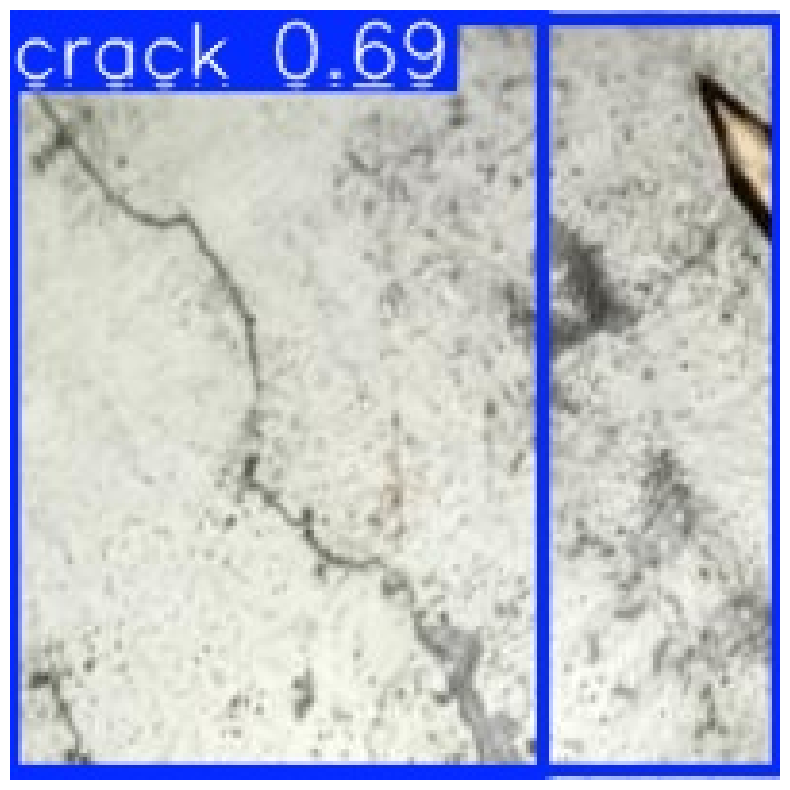

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Find the most recent prediction folder
all_predict_folders = glob.glob('/content/runs/detect/predict*/')
if not all_predict_folders:
    print("No predict folders found. Run the '!yolo predict' command first.")
else:
    latest_folder = max(all_predict_folders, key=os.path.getmtime)
    predicted_images = glob.glob(os.path.join(latest_folder, '*.jpg'))

    if predicted_images:
        # We use square brackets here
        final_img_path = predicted_images[0]
        print(f"Found image: {final_img_path}")

        # Show the image
        img = Image.open(final_img_path)
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        # Download the image
        files.download(final_img_path)
    else:
        print("No images found in the latest predict folder.")